## Review gradient descent in two dimensions

In this lesson, we'll learn about gradient descent in three dimensions, but let's first remember how it worked in two dimensions when we changed just one variable of our regression line.  

In two dimensions, when changing just one variable, $m$ or $b$, gradient descent means stepping forwards or backwards along the cost curve and taking a specific step size.  To determine whether to move forwards or backwards as well as the step size, we imagine standing on this two-dimension curve (shown below) and feeling the slope of our cost curve to tell us how to move.  A step in a direction means a change in one of our regression variables.

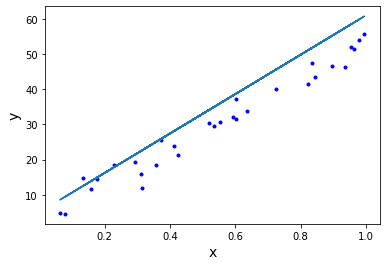

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
np.random.seed(225)

def regression_formula(x):
    return 5 + 56*x

x = np.random.rand(30,1).reshape(30)
y_randterm = np.random.normal(0,3,30)
y = 3+ 50* x + y_randterm

plt.plot(x, y, '.b')
plt.plot(x, regression_formula(x), '-')
plt.xlabel("x", fontsize=14)
plt.ylabel("y", fontsize=14);

As we adjust to different slopes, we achieve different errors, represented by RSS.

![](./assets/gradient_descent_advanced/slopes.png)

So that is how gradient descent is represented in two dimensions. How is gradient descent represented in three dimensions?

## Gradient Descent in 3 dimensions

In three dimensions, we once again choose an initial regression line, which means that we are choosing a point on the graph below.  Then we begin taking steps towards the minimum.  But of course, we are now able to walk not just forwards and backwards but left and right as well -- as we now can alter two variables.

<img src="./assets/gradient_descent_advanced/new_gradientdescent.png" width="600">

To get a sense of how this works, imagine our initial regression line places us at the back-left corner of the graph above, with a slope of 50, and y-intercept of negative 20.  Now imagine that we cannot see the rest of the graph - yet we still want to approach the minimum.  How do we do this?

Once again, we feel out the slope of the graph with our feet.  Only this time, as we shift our feet, we are preparing to walk in two-dimensional space.

![](./assets/gradient_descent_advanced/traveller-stepping.jpg)

So this is our approach.  We shift horizontally a little bit to determine the change in output in the right-left direction, and then we shift forward and back to determine the change in output in that direction.  From there we take the next step in the direction of the steepest descent. 

So this is why our technique of gradient descent is so powerful.  Once we consider that in moving towards our best fit lines, we have a choice of moving anywhere in a two-dimensional space, then using the slope to guide us only becomes more important.

So how does this approach of shifting back and forth translate mathematically?  It means we determine the slope in one dimension, then the other. Then, we move where that slope is steepest downwards.  This moves us towards our minimum.

## Partial Derivatives

To measure the slope in each dimension, one after the other, we'll take the derivative with respect to one variable, and then take the derivative with respect to another variable.  Now let's be very explicit about what it means to take the partial derivative with respect to a variable.

Let's again talk about this procedure in general, and then we'll apply it to the cost curve.  So let's revisit our multivariable function: 

$$f(x, y) = y*x^2 $$

Remember that the function looks like the following: 

<img src="./assets/gradient_descent_advanced/new_parabolayx2.png" width="400">

To take a derivative with respect to $x$ means to ask, how does the output change, as we make a nudge only in the $x$ direction. To express that we are nudging in the $x$ direction we say $\frac{\delta f}{\delta x}$.  That symbol is the lower case delta.  We read this as taking the derivative with respect to $x$.  But it just means seeing the change in output as we nudge in the $x$ direction.  

And to express the change in output with respect to $y$, we say $\frac{\delta f}{\delta y}$.  And this just means calculating the change in output as we nudge our input over in the $y$ direction.

## Visualizing the partial derivative

So what does a derivative $\frac{\delta f}{\delta x}$ look like? How do we think of a partial derivative of a multivariable function?

Well, remember how we think of a standard derivative of a one variable function, for example $f(x) = x^2 $.

![](./assets/gradient_descent_advanced/tangent-liner.png)

So in two dimensions, to take the derivative at a given point, we simply calculate the slope of the function at that x value.

Now the partial derivative of a multivariable function is fairly similar.  But here it's equal to the slope of the tangent line at a specific $x$ value **and** a specific $y$ value.  Let's break this down by using our patented "freeze-frame" method.  The graphs below show lines tangent to the curve in the $x$ direction.  (The tangent lines are a little small, but they and their corresponding slopes are there).

### Graphs for $\frac{df}{dx}$

<img src="assets/gradient_descent_advanced/dfdx.png" width="800">

Let's take a close look.  The top-left graph shows $\frac{\delta f}{\delta x}$ at different points of $f(x, y)$ where $y = -1$.  So as you can see, $\frac{\delta f}{\delta x}f(3, -1) = -6$ as shown in the cyan line in the top left.  That's because when you move to that point on the graph, $(3, -1)$ and then nudge a little bit in the $x$ direction, the change in output is $-6$.  And that is represented by the line tangent to the function at that point in the $x$ direction.  You can go through the other points in these graphs, and work through the same logic.

So with taking the partial derivative $\frac{\delta f}{\delta x}$, you may think about moving to the slice of the graph for a given value of $y$, then moving to the proper value of $x$, and then finding the tangent line at that point.  

As you can see, $\frac{\delta f}{dx}$ means the change in output from a nudge in $x$ direction, but the derivative is still influenced by $y$ component of the function.  You can see this because, for different values of $y$, our slice of the graph looks different, and thus tangent lines for those slices look different.

## One more example

This can be a little mind-bending so let's go through this again for $\frac{df}{dy}f(x, y)$ where $f(x,y) = (yx^2) $.  Once again, the 3-d graph of $f(x,y) = yx^2$ is the following: 

<img src="./assets/gradient_descent_advanced/new_parabolayx2.png" width="400">

Now for $\frac{df}{dy}$ of a function $f(x, y) $ you can think sliding through different slices of the function but this time for different values of $x$.  So again, we have our freeze-frame, but this time each frame represents ascending values along the x-axis.  

First, let's understand our plots below -- they may be surprising.  Starting at the top left quadrant the graph of the function $f(x,y)$ makes sense as when $x =-1$ then the function is just $f(y) = -1*y $.  And moving down to the bottom left, $f(2, y) = 2^2*y = 4y$.  

So now, to think about taking the derivative, once again we move to a slice of graph for a value of $x$, and then move in the $y$ direction.  So $\frac{df}{dy}$ at $\frac{df}{dy}f(1, y)$ = 1.  And we know that the derivative of a line is always just equal to the line's slope.  For $f(1, y)$ that slope, and thus the derivative, is always $1$.  For $f(2, y)$ it's 4.

### Graphs for $\frac{df}{dy}$

<img src="assets/gradient_descent_advanced/dfdy.png" width="800">

So that is our technique for a partial derivative.  For $\frac{df}{dy} $ we move to a slice of the curve at a specific value of $x$, move to the point for y, and then calculate the change in output as we nudge in the $y$ direction.  

For $\frac{df}{dx}$ (again below), we move to a slice of a curve of a specific value of $y$, move the correct value of $x$ and then calculate how much the output changes as we nudge in the $y$ direction.  Just think slide, slide then nudge.  That's a partial derivative.

### Graphs for $\frac{df}{dx}$

<img src="assets/gradient_descent_advanced/dfdx.png" width="800">

## Our rule for partial derivatives

Ok, so now that you understand the slide, slide, nudge, maybe you can understand this little shortcut that we can pull.  For any multivariable function, the variables that you are **not** taking the derivative with respect to can just be treated as a constant.

For example, with our function of $f(x, y) = y*x^2 $, when taking the partial derivative $\frac{df}{dy}f(x, y)$, we treat all values of $x$ as a constant.  Let's do it:


$$\frac{df}{dy}f(x,y) =  \frac{df}{dy}(y) * x^2 = 1*x^2 = x^2$$

So that's all it means to take a partial derivative of something: look at what you are taking a derivative with respect to, and only take the derivative of those types of variables.  And guess what, this result lines up to what we saw earlier.

<img src="assets/gradient_descent_advanced/dfdy.png" width="800">

We calculated that $\frac{df}{dy}f(x,y) = x^2 $, and that is what the graphs show.  When $x = 2$ our derivative is always 4.  And when $x$ is $3$ the derivative is always 9.  So even though we are taking $\frac{df}{dy}$, the $x$ value is influencing the steepness of that line.  But by the time we get to our nudge, that value of $x$ is **constant**, it's influenced has already been applied, and then we are seeing how the output changes as we nudge in the $y$ direction.

Now let's try our rule one more time, this time $\frac{df}{dx}f(x, y)$ for our function $f(x, y) = y*x^2 $.



$$\frac{df}{dx}f(x,y) = y*\frac{df}{dx}(x^2) = 2*y*x$$

So this time with $\frac{df}{dx}f(x,y) $, we treat $y$ as a constant, as the influence $y$ is first applied by moving to a slice of our graph for a value of $y$.  Then once there, we are evaluating the change in output as we nudge in the $x$ direction.

<img src="assets/gradient_descent_advanced/dfdx.png" width="800">

## Representing RSS as a multivariable function

Think about why gradient descent applies so well to a cost function.  Initially, we said that the cost of our function, meaning the difference between what our regression line predicted and the dataset, changed as we altered the y-intercept or the slope of the function.

Remember that mathematically, when we say cost function, we use the residual sum of squares where 
$$ 
\begin{align}
RSS &= \sum_{i=1}^n(actual - expected)^2 \\
&= \sum_{i=1}^n(y_i - \hat{y})^2 \\
&= \sum_{i=1}^n(y_i - (mx_i + b))^2
\end{align}
$$ 
for all $x$ and $y$ values of our dataset.  So in the graph directly below, $x_i$ and $y_i$  would be our points representing a movie's budget and revenue.  Meanwhile, $mx_i + b $ is our predicted $y$ value for a given $x$ value, of a budget. 

And RSS takes the difference between $mx_i + b$, the $y_i$ value our regression line (the red line below) predicts, and our actual $y$, and sum up these squares for each piece of data in our dataset.  That is the residual sum of squares.

Text(0, 0.5, 'y')

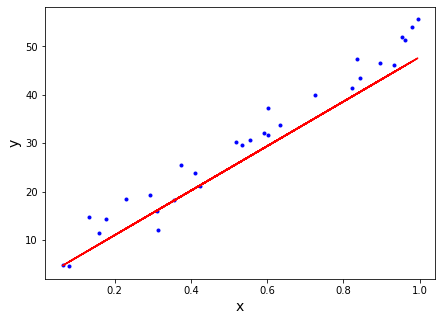

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def regression_formula(x):
    return 1.8 + 46*x

np.random.seed(225)

x = np.random.rand(30,1).reshape(30)
y_randterm = np.random.normal(0,3,30)
y = 3+ 50* x + y_randterm

plt.figure(figsize=(7,5))
plt.plot(x, y, '.b')
plt.plot(x, regression_formula(x), '-', color="red")
plt.xlabel("x", fontsize=14)
plt.ylabel("y", fontsize=14)

And we when we just plotted how RSS changes as we change one variable of our regression line, $m$ or $b$, we note how this looks like a curve, and call it our cost curve.

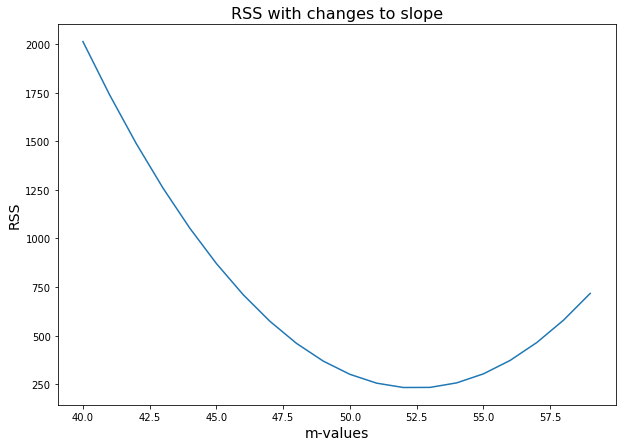

In [ ]:
def errors(x_values, y_values, m, b):
    y_line = (b + m*x_values)
    return (y_values - y_line)

def squared_errors(x_values, y_values, m, b):
    return np.round(errors(x_values, y_values, m, b)**2, 2)

def residual_sum_squares(x_values, y_values, m, b):
    return round(sum(squared_errors(x_values, y_values, m, b)), 2)

table = np.zeros((20,2))
for idx, val in enumerate(range(40, 60)):
    table[idx,0] = val
    table[idx,1] = residual_sum_squares(x, y, val, 1.319)
    
plt.figure(figsize=(10,7))
plt.plot(table[:,0], table[:,1], '-')
plt.xlabel("m-values", fontsize=14)
plt.ylabel("RSS", fontsize=14)
plt.title("RSS with changes to slope", fontsize=16);

In two dimensions, we decrease our RSS simply by moving forwards or backwards along the cost curve which is the equivalent of changing our variable, in this case y-intercept.  So the cost curve above indicates that changing the regression line from having a $m$ slope from 42 to 45 decreases our cost, the RSS.

Allowing us to change both variables, $m$ and $b$ means calculating how RSS varies with both $m$ and $b$.

Because the RSS is a function of how we change our values of $m$ and $b$, we can express this relationship mathematically by saying the cost function, $J$ is the following:  
$$
\begin{align}
J(m, b) & = \sum_{i=1}^{n}(y_i - \hat{y})^2\\
J(m, b) & = \sum_{i=1}^{n}(y_i - (mx_i + b))^2 &&\text{notice $\hat{y} = mx + b$}\\
\end{align}
$$

In the function above, $J$ is a function of $m$ and $b$. $J$ just represents the residual sum of squares, which varies as the $m$ and $b$ variables of our regression line are changed.

Just our other multivariable functions we have seen thus far, we can display it in three dimensions, and it looks like the following.

<img src="./assets/gradient_descent_advanced/new_gradientdescent.png" width="600">

The three-dimensional graph above shows how the cost associated with our regression line changes as the slope and y-intercept values are changed.

## Calculating the gradient of our cost function

Let's explore using gradient descent to determine how to change our regression line when we can alter both $m$ and $b$ variables.  When applied to a general multivariable function $f(x,y)$, gradient descent answered how much move the $x$ variable and the $y$ variable to produce the greatest decrease in output.  

> Now that we are applying gradient descent to our cost curve $J(m, b)$, the technique should answer how much to move the $m$ variable and the $b$ variable to produce the greatest decrease in cost, or RSS. In other words, when altering our regression line, we want to know how much of this change should be derived from a move in the slope versus how much should be derived from a change in the y-intercept.

As we know, the gradient of a function is simply the partial derivatives with respect to each of the variables, so:

$$ \nabla J(m, b) = \frac{\delta J}{\delta m}, \frac{\delta J}{\delta b}$$

In calculating the partial derivatives of our function $J(m, b) = \sum_{i=1}^{n}(y_i - (mx_i + b))^2$, **we won't change the result if we ignore the summation until the very end**.  We'll do that to make our calculations easier.

Ok, so let's take our partial derivatives of the following:

$$
\begin{align}
\frac{\delta J}{\delta m}J(m, b) & = \boldsymbol{\frac{\delta J}{\delta m}}(y - (mx + b))^2  &&\text{partial derivative with respect to} \textbf{ m}\\
\\
\frac{\delta J}{\delta b}J(m, b) & = \boldsymbol{\frac{\delta J}{\delta b}}(y - (mx + b))^2  &&\text{partial derivative with respect to} \textbf{ b}\\
\end{align}
$$

You'll notice that taking the partial derivatives of these functions is not that simple. You've learned a set of rules about derivatives in this section, but if you want to take these two derivatives successfully, you'll need to use the **chain rule**. The chain rule is a formula to compute the derivative of a composite function.

The **chain rule** basically tells you how to compute the derivative of nearly _any function_ (or any "molecular" function built up from fundamental "atomic" functions like $sin(x)$ or $e^x$).

In this lesson, we don't want to get lost in the details of the chain rule and how to get to the the partial derivatives needed in this lesson, but in the appendix, you can find:
- a lesson on the chain rule in general
- A lesson that walks you through the details of finding the partial derivatives in this lesson.

The resulting partial derivatives are:

$$
\begin{align}
\frac{\delta J}{\delta m}J(m, b)&= -2x*(y - (mx + b ))
\end{align}
$$

$$
\begin{align}
\frac{\delta J}{\delta b}J(m, b) & = -2*(y - (mx + b))
\end{align}
$$

## Using both of our partial derivatives for gradient descent

Ok, so now we have our two partial derivatives for $\nabla J(m, b)$:

$$ \frac{dJ}{dm}J(m,b) = -2*x(y - (mx + b )) $$
$$ \frac{dJ}{db}J(m,b) = -2*(y - (mx + b)) $$

And as $mx + b$ = is just our regression line, we can simplify these formulas to be: 

$$ \frac{dJ}{dm}J(m,b) = -2*x(y - \hat{y})  = -2x*\epsilon$$
$$ \frac{dJ}{db}J(m,b) = -2*(y - \hat{y}) = -2\epsilon$$

Remember, `error` = `actual` - `expected`, so we can replace $y - \hat{y}$ with $\epsilon$, our error. As we mentioned above, our last step is adding back the summations.  Since $-2$ is a constant, we can keep this outside of the summation.  Our value for $x$ changes depending upon what x value we are at, so it must be included inside the summation for the first equation.  Below, we have: 

$$ \frac{dJ}{dm}J(m,b) = -2*\sum_{i=1}^n x(y_i - \hat{y}_i)  = -2*\sum_{i=1}^n x_i*\epsilon_i$$
$$ \frac{dJ}{db}J(m,b) = -2*\sum_{i=1}^n(y_i - \hat{y}_i) = -2*\sum_{i=1}^n \epsilon_i$$

So that is what what we'll do to find the "best fit regression line."  We'll start with an initial regression line with values of $m$ and $b$.  Then we'll go through our dataset, and we will use the above formulas with each point to tell us how to update our regression line such that it continues to minimize our cost function.

In the context of gradient descent, we use these partial derivatives to take a step size.  Remember that our step should be in the opposite direction of our partial derivatives as we are *descending* towards the minimum.  So to take a step towards gradient descent we use the general formula of:

`current_m` =  `old_m` $ - \frac{dJ}{dm}J(m,b)$

`current_b` =  `old_b` $ - \frac{dJ}{db}J(m,b) $

or in the code that we just calculated:

`current_m` = `old_m` $ -  (-2*\sum_{i=1}^n x_i*\epsilon_i )$

`current_b` =  `old_b` $ - ( -2*\sum_{i=1}^n \epsilon_i )$

In the next lesson, we'll work through translating this technique, with use of our $\nabla J(m, b)$, into code to descend along our cost curve and find the "best fit" regression line.

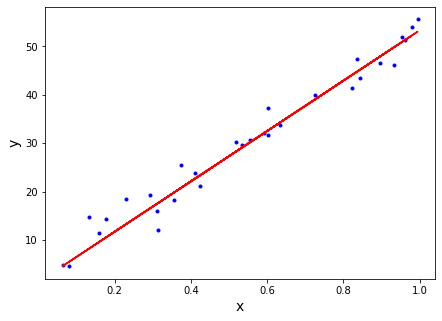

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def regression_formula(x):
    return 1.319 + 52*x

np.random.seed(225)

x = np.random.rand(30,1).reshape(30)
y_randterm = np.random.normal(0,3,30)
y = 3+ 50* x + y_randterm

plt.figure(figsize=(7,5))
plt.plot(x, y, '.b')
plt.plot(x, regression_formula(x), '-', color="red")
plt.xlabel("x", fontsize=14)
plt.ylabel("y", fontsize=14);

## What is the gradient?

Now gradient descent literally means that we are taking the shortest path to *descend* towards our minimum.  However, it is somewhat easier to understand gradient *ascent* than descent, and the two are quite related, so that's where we'll begin.  Gradient ascent, as you could guess, simply means that we want to move in the direction of steepest ascent.

Now moving in the direction of greatest ascent for a function $f(x,y)$, means that our next step is a step some distance in the $x$ direction and some distance in the $y$ direction which is the steepest upward at that point.

Note how this is a different task from what we have previously worked on for multivariable functions.   So far, we have used partial derivatives to calculate the **gain** from moving directly in either the $x$ direction or the $y$ direction.  

> Here, in finding gradient ascent, our task is not to calculate the gain from a move in either the $x$ or $y$ direction.  Instead, our task is to **find some combination of a change in $x$,$y$ that brings the largest change in output**.  

So if you look at the path our climbers are taking in the picture above, *that* is the direction of gradient ascent.  If they tilt their path to the right or left, they will no longer be moving along the steepest upward path.

The direction of the greatest rate of increase of a function is called the gradient.  We denote the gradient with the nabla, which comes from the Greek word for harp, which is kind of what it looks like: $\nabla $.  So we can denote the gradient of a function, $f(x, y)$, with $\nabla f(x, y) $.

## Calculating the gradient

Now how do we find the direction for the greatest rate of increase?  We use partial derivatives.  Here's why.

As we know, the partial derivative $\frac{df}{dx}$ calculates the change in output from moving a little bit in the $x$ direction, and the partial derivative $\frac{df}{dy}$ calculates the change in output from moving in the $y$ direction.  Because with gradient ascent our goal is to make a nudge in $x, y$ that produces the greatest change in output, if $\frac{df}{dy} > \frac{df}{dx}$, we should make that move more in the $y$ direction than the $x$ direction, and vice versa.  That is, we want to get the biggest bang for our buck.  

![](./assets/gradient_descent_advanced/Denali.jpg)

Let's relate this again to mountain climbers. Imagine the vertical edge on the left is our y-axis and the horizontal edge is on the bottom is our x-axis.  For the climber in the yellow jacket, imagine his step size is three feet. A step straight along the y-axis will move him further upwards than a step along the x-axis.  So in taking that step, he should direct himself more towards the y-axis than the x-axis.  That will produce a bigger increase per step size.

In fact, the direction of greatest ascent for a function,  $\nabla f(x, y)$, is the direction which is a proportion of $\frac{df}{dy}$ steps in the $y$ direction and $\frac{df}{dx}$ in the $x$ direction.  So, for example, if $\frac{df}{dy}$ = 5 and $\frac{df}{dx}$ = 1, the direction of gradient ascent is five times more in the $y$ direction than the $x$ direction.  And this seems to be the path, more or less that our climbers are taking - some combination of $x$ and $y$, but tilted more towards the $y$ direction.

## Applying Gradient Descent

Now that we have a better understanding of a gradient, let's apply our understanding to a multivariable function.  Here is a plot of a function:

$$f(x,y) = 2x + 3y $$

<img src="./assets/gradient_descent_advanced/new_gradDescinDesc.png" width="400">

Imagine being at the bottom left of the graph at the point $x = 1$, $y = 1$.  What would be the direction of steepest ascent?  It seems, just sizing it up visually, that we should move both in the positive $y$ direction and the positive $x$ direction.  Looking more carefully, it seems we should move **more** in the $y$ direction than the $x$ direction.  Let's see what our technique of taking the partial derivative indicates.

The gradient of the function $f(x,y)$, that is $ \nabla f(x,y) = 2x + 3y $ is the following: 

$\frac{df}{dx}(2x + 3y) = 2 $ and $\frac{df}{dy}(2x + 3y) = 3 $.

So what this tells us is to move in the direction of greatest ascent for the function $f(x,y) = 2x + 3y $, is to move up three and to the right two.  So we would expect our path of greatest ascent to look like the following.

![](./assets/gradient_descent_advanced/gradient-plot.png)

<img src="./assets/gradient_descent_advanced/new_gradDescinDesc.png" width="400">

So this path maps up well to what we see visually.  That is the idea behind gradient descent.  The gradient is the partial derivative with respect to each type of variable of a multivariable function, in this case $x$ and $y$.  And the importance of the gradient is that its direction is the direction of steepest ascent.  The negative gradient, that is the negative of each of the partial derivatives, is the direction of steepest descent.  So our direction of gradient descent for the graph above is $x = -2$, $y = -3$.  And looking at the two graphs above, it seems that the steepest downward direction is just the opposite of the steepest upward direction.  We get that by mathematically by simply taking the multiplying our partial derivatives by negative one.

## Reviewing our gradient descent formulas

Luckily for us, we already did the hard work of deriving these formulas.  Now we get to see the fruit of our labor.  The following formulas tell us how to update regression variables of $m$ and $b$ to approach a "best fit" line.   

- $ \frac{dJ}{dm}J(m,b) = -2\sum_{i = 1}^n x_i(y_i - (mx_i + b)) = -2\sum_{i = 1}^n x_i*\epsilon_i$ 
- $ \frac{dJ}{db}J(m,b) = -2\sum_{i = 1}^n(y_i - (mx_i + b)) = -2\sum_{i = 1}^n \epsilon_i $

Now the formulas above tell us to take some dataset, with values of $x$ and $y$, and then given a regression formula with values $m$ and $b$, iterate through our dataset, and use the formulas to calculate an update to $m$ and $b$.  So ultimately, to descend along the cost function, we will use the calculations:

`current_m` = `old_m` $ -  (-2*\sum_{i=1}^n x_i*\epsilon_i )$

`current_b` =  `old_b` $ - ( -2*\sum_{i=1}^n \epsilon_i )$

Ok let's turn this into code.  First, let's initialize our data like we did before:

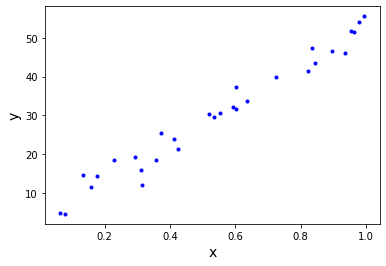

In [ ]:
import numpy as np
np.set_printoptions(formatter={'float_kind':'{:f}'.format})
import matplotlib.pyplot as plt
%matplotlib inline
np.random.seed(225)

x = np.random.rand(30, 1).reshape(30)
y_randterm = np.random.normal(0,3,30)
y = 3 + 50* x + y_randterm

data = np.array([y, x])
data = np.transpose(data)

plt.plot(x, y, '.b')
plt.xlabel("x", fontsize=14)
plt.ylabel("y", fontsize=14);

Now

- Let's set our initial regression line by initializing $m$ and $b$ variables as zero.  Store them in `b_current` and `m_current`.
- Let's next initialize updates to these variables by setting the variables, `update_to_b` and `update_to_m` equal to 0.
- Define an `error_at` function which returns the error $\epsilon_i$ for a given $i$. The parameters are:
> point: a row of the particular data set  
> $b$: the intercept term  
> $m$: the slope  

- Them, use this `error_at` function to iterate through each of the points in the dataset, and at each iteration change our `update_to_b` by $2*\epsilon$ and change our `update_to_m` by $2*x*\epsilon$.

In [ ]:
# initial variables of our regression line
b_current = 0
m_current = 0

#amount to update our variables for our next step
update_to_b = 0
update_to_m = 0 

# Define the error_at function
def error_at(point, b, m):
    return (point[0]- (m * point[1]  + b))

# iterate through data to change update_to_b and update_to_m
for i in range(0, len(data)):
    update_to_b += -2*(error_at(data[i], b_current, m_current))
    update_to_m += -2*(error_at(data[i], b_current, m_current))*data[i][1]

# Create new_b and new_m by subtracting the updates from the current estimates
new_b = b_current - update_to_b
new_m = m_current - update_to_m

In the last two lines of the code above, we calculate our `new_b` and `new_m` values by updating our taking our current values and adding our respective updates.  We define a function called `error_at`, which we can use in the error component of our partial derivatives above.

The code above represents **just one** update to our regression line, and therefore just one step towards our best fit line.  We'll just repeat the process to take multiple steps.  But first, we have to make a couple of other changes. 

## Tweaking our approach 

Ok, the above code is very close to what we want, but we just need to make tweaks to our code before it's perfect.

The first one is obvious if we think about what these formulas are really telling us to do.  Look at the graph below, and think about what it means to change each of our $m$ and $b$ variables by at least the sum of all of the errors, of the $y$ values that our regression line predicts and our actual data.  That would be an enormous change.  To ensure that we drastically updating our regression line with each step, we multiply each of these partial derivatives by a learning rate.  As we have seen before, the learning rate is just a small number, like $.
01$ which controls how large our updates to the regression line will be.  The learning rate is  represented by the Greek letter eta, $\eta$, or alpha $\alpha$.  We'll use eta, so $\eta = .01$ means the learning rate is $.01$.

Multiplying our step size by our learning rate works fine, so long as we multiply both of the partial derivatives by the same amount.  This is because without gradient,  $ \nabla J(m,b)$, we think of as steering us in the correct direction.  In other words, our derivatives ensure we are making the correct **proportional** changes to $m$ and $b$.  So scaling down these changes to make sure we don't update our regression line too quickly works fine, so long as we keep me moving in the correct direction.  While we're at it, we can also get rid of multiplying our partials by 2.  As mentioned, so long as our changes are proportional we're in good shape. 

For our second tweak, note that in general the larger the dataset, the larger the sum of our errors would be.  But that doesn't mean our formulas are less accurate, and there deserve larger changes.  It just means that the total error is larger.  But we should really think accuracy as being proportional to the size of our dataset.  We can correct for this effect by dividing the effect of our update by the size of our dataset, $n$.

Make these changes below:

In [ ]:
#amount to update our variables for our next step
update_to_b = 0
update_to_m = 0 

# define learning rate and n
learning_rate = .01
n = len(data)

# create update_to_b and update_to_m
for i in range(0, n):
    update_to_b += -(1/n)*(error_at(data[i], b_current, m_current))
    update_to_m += -(1/n)*(error_at(data[i], b_current, m_current)*data[i][0])
    
# create new_b and new_m
new_b = b_current - (learning_rate * update_to_b)
new_m = m_current - (learning_rate * update_to_m)

So our code now reflects what we know about our gradient descent process.  Start with an initial regression line with values of $m$ and $b$.  Then for each point, calculate how the regression line fares against the actual point (that is, find the error).  Update what the next step to the respective variable should be by using the partial derivative.  And after iterating through all of the points, update the value of $b$ and $m$ appropriately, scaled down by a learning rate.

## Seeing our gradient descent formulas in action

As mentioned earlier, the code above represents just one update to our regression line, and therefore just one step towards our best fit line.  To take multiple steps we wrap the process we want to duplicate in a function called `step_gradient` and then can call that function as much as we want. With this function:

- Include a learning_rate of 0.1
- Return a tuple of (b,m)  
The parameters should be:
> b_current : the starting value of b   
> m_current : the starting value of m   
> points : the number of points at which we want to check our gradient 

See if you can use your `error_at` function within the `step_gradient` function!

In [ ]:
def step_gradient(b_current, m_current, points):
    b_gradient = 0
    m_gradient = 0
    learning_rate = .1
    N = float(len(points))
    for i in range(0, len(points)):
        x = points[i][1]
        y = points[i][0]
        b_gradient += -(1/N) * (y - (m_current * x + b_current))
        m_gradient += -(1/N) * x * (y -  (m_current * x + b_current))
    new_b = b_current - (learning_rate * b_gradient)
    new_m = m_current - (learning_rate * m_gradient)
    return (new_b, new_m)

Now let's initialize `b` and `m` as 0 and run a first iteration of the `step_gradient` function.

In [ ]:
b = 0
m = 0
first_step = step_gradient(b, m, data) # {'b': 0.0085, 'm': 0.6249999999999999}

print(first_step[0])
print(first_step[1])
# b= 3.02503, m= 2.07286

3.0250308395837813
2.0728619246505193


So just looking at input and output, we begin by setting $b$ and $m$ to 0 and 0.  Then from our step_gradient function, we receive new values of $b$ and $m$ of 3.02503 and 2.0728.  Now what we need to do, is take another step in the correct direction by calling our step gradient function with our updated values of $b$ and $m$.

In [ ]:
updated_b = first_step[0]
updated_m = first_step[1]
step_gradient(updated_b, updated_m, data) 
# b = 5.63489, m= 3.902265

(5.634896312558807, 3.902265648903966)

Let's do this, say, 1000 times.

In [ ]:
# set our initial step with m and b values, and the corresponding error.
b = 0
m = 0
iterations = []
for i in range(1000):
    iteration = step_gradient(b, m, data)
    b = iteration[0]
    m = iteration[1]
    # update values of b and m
    iterations.append(iteration)

Let's take a look at the estimates in the last iteration.

In [ ]:
iterations[999]

(3.1619764855577257, 49.84313430300858)

As you can see, our  m  and  b  values both update with each step. Not only that, but with each step, the size of the changes to  m and  b  decrease. This is because they are approaching a best fit line.

## Let's include 2 predictors, $x_1$ and $x_2$

Below, we generated a problem where we have 2 predictors. We generated data such that the best fit line is around $\hat y = 3x_1 -4x_2 +2$, noting that there is random noise introduced, so the final result will never be exactly that. Let's build what we built previously, but now create a `step_gradient_multi` function that can take an *arbitrary* number of predictors (so the function should be able to include more than 2 predictors as well). Good luck!

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
np.random.seed(11)

x1 = np.random.rand(100,1).reshape(100)
x2 = np.random.rand(100,1).reshape(100)
y_randterm = np.random.normal(0,0.2,100)
y = 2+ 3* x1+ -4*x2 + y_randterm

data = np.array([y, x1, x2])
data = np.transpose(data)

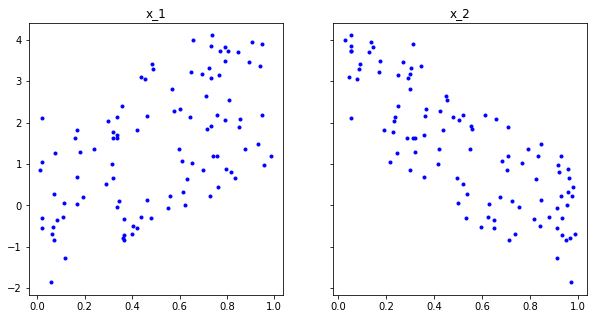

In [ ]:
f, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5), sharey=True)
ax1.set_title('x_1')
ax1.plot(x1, y, '.b')
ax2.set_title('x_2')
ax2.plot(x2, y, '.b');

Note that, for our gradients, when having multiple predictors $x_j$ with $j \in 1,\ldots, k$

$$ \frac{dJ}{dm_j}J(m_j,b) = -2\sum_{i = 1}^n x_{j,i}(y_i - (\sum_{j=1}^km{x_{j,i}} + b)) = -2\sum_{i = 1}^n x_{j,i}*\epsilon_i$$
$$ \frac{dJ}{db}J(m_j,b) = -2\sum_{i = 1}^n(y_i - (\sum_{j=1}^km{x_{j,i}} + b)) = -2\sum_{i = 1}^n \epsilon_i $$
    

So we'll have one gradient per predictor along with the gradient for the intercept!

Create the `step_gradient_multi` function below. As we said before, this means that we have more than one feature that we are using as an independent variable in the regression. This function will have the same inputs as `step_gradient`, but it will be able to handle having more than one value for m. It should return the final values for b and m in the form of a tuple.

- `b_current` refers to the y-intercept at the current step
- `m_current` refers to the slope at the current step
- `points` are the data points to which we want to fit a line

You might have to refactor your `error` at function if you want to use it with multiple m values.

In [ ]:
def step_gradient_multi(b_current, m_current ,points):
    b_gradient = 0
    m_gradient = np.zeros(len(m_current))
    learning_rate = .1
    N = float(len(points))
    for i in range(0, len(points)):
        y = points[i][0]
        x = points[i][1:(len(m_current)+1)] 
        b_gradient += -(1/N)  * (y -  (sum(m_current * x) + b_current))
        m_gradient += -(1/N) * x * (y -  (sum(m_current * x) + b_current))
    new_b = b_current - (learning_rate * b_gradient)
    new_m = m_current - (learning_rate * m_gradient)
    return (new_b, new_m)

Apply 1 step to our data

In [ ]:
b = 0
m = [0,0]
updated_b, updated_m = step_gradient_multi(b, m, data) # {'b': 0.0085, 'm': 0.6249999999999999}
print(updated_b, updated_m)

0.13965491088061555 [0.093847 0.038762]


Apply 500 steps to our data

In [ ]:
# set our initial step with m and b values, and the corresponding error.
b = 0
m = [0,0]
iterations = []
for i in range(500):
    iteration = step_gradient_multi(b, m, data)
    b= iteration[0]
    m = []
    for j in range(len(iteration)):
        m.append(iteration[1][j])
    iterations.append(iteration)

Look at the last step

In [ ]:
iterations[499]

(1.944428332442866, array([2.995890, -3.911055]))